## Energy Consumption Analysis

In [125]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from pandas.api.types import CategoricalDtype

In [ ]:
df = pd.read_csv('../data/Steel_industry_data.csv')
df.head()

,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type
0,01/01/2018 00:15,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load
1,01/01/2018 00:30,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load
2,01/01/2018 00:45,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load
3,01/01/2018 01:00,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load
4,01/01/2018 01:15,3.82,4.50,0.0,0.0,64.72,100.0,4500,Weekday,Monday,Light_Load


### Energy Usage Distribution

In [68]:
# descriptive statistics
df['Usage_kWh'].describe()

count    35040.000000
mean        27.386892
std         33.444380
min          0.000000
25%          3.200000
50%          4.570000
75%         51.237500
max        157.180000
Name: Usage_kWh, dtype: float64

Findings: The mean Usage_kWh is considerably larger than the median, possibly indicating the influence of large values or outliers. The standard deviation is relatively large compared with the mean, indicating substantial variation in energy consumption. The large difference between the median and upper quartiles indicate significant variation in consumption. all these suggests that the distribution may be skewed to one side.
Things that may need further investigation: the minimum value being zero, is that a valid value or a value taken at a non-operating condition?, also, whether the high values are genuine values or are errors in data collection

Text(0.5, 1.0, 'Histogram of Energy Usage')

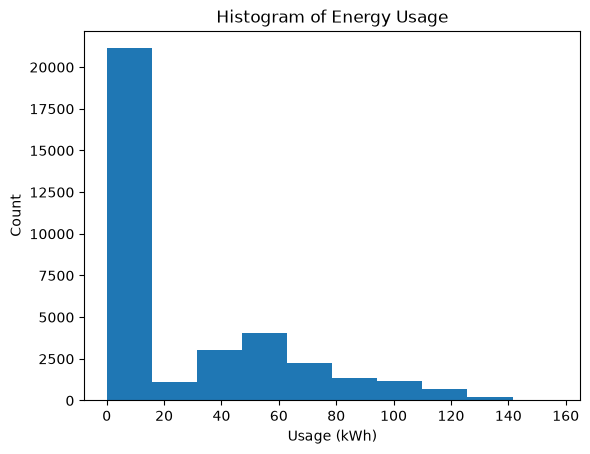

In [69]:
# plotting a histogram
fig, ax = plt.subplots()
ax.hist(df['Usage_kWh'])
ax.set_xlabel('Usage (kWh)')
ax.set_ylabel('Count')
ax.set_title('Histogram of Energy Usage')

Findings: The distribution is highly concentrated at low consumption levels and contains a second region of considerably higher consumption, followed bu a long upper tail. this suggests that different operating conditions may influence energy usage.

### Load Type

In [70]:
# frequency of each load type category
print(df['Load_Type'].value_counts())
print(df['Load_Type'].value_counts(normalize= True)*100)

Load_Type
Light_Load      18072
Medium_Load      9696
Maximum_Load     7272
Name: count, dtype: int64
Load_Type
Light_Load      51.575342
Medium_Load     27.671233
Maximum_Load    20.753425
Name: proportion, dtype: float64


Does the distribution of energy consumption differ between light, medium and maximum load conditions?

Text(0, 0.5, 'Energy usage')

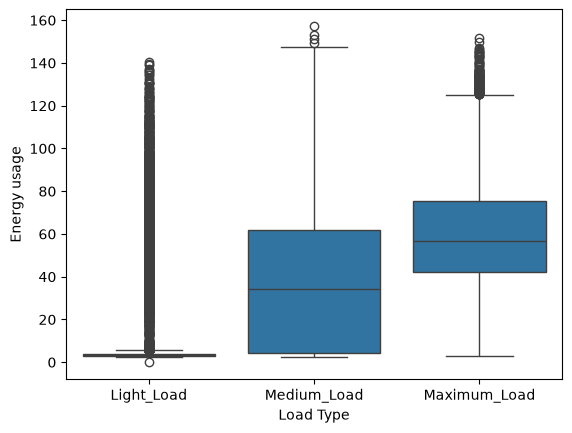

In [132]:
fig,ax = plt.subplots()
sns.boxplot(data =df, x = 'Load_Type', y = 'Usage_kWh')
ax.set_xlabel('Load Type')
ax.set_ylabel('Energy usage')

In [73]:
# desccriptive statistics for each load type
df.groupby('Load_Type')['Usage_kWh'].describe().sort_values(by = '50%')

,count,mean,std,min,25%,50%,75%,max
Load_Type,,,,,,,,
Light_Load,18072.0,8.626207,17.906245,0.00,2.9500,3.310,4.03,140.29
Medium_Load,9696.0,38.445394,35.220166,2.52,4.4200,34.435,61.70,157.18
Maximum_Load,7272.0,59.265314,29.749700,2.92,42.0025,56.630,75.31,151.67


Findings: the median of the groups increases from light to medium to maximum load which could mean that higher load type categories are associated with higher energy usage, however values within each group overlap considerably, making the relationship less clear. There is also a large number of 'outliers' in the light load group because values in the group seriously exceed the max value calculated by Q3+1.5IQR. This requires further investigation, as it could be due to mislabelling or because factors other than load type also influence energy usage.

### Time of Day

Text(0.5, 1.0, 'Usage against Time')

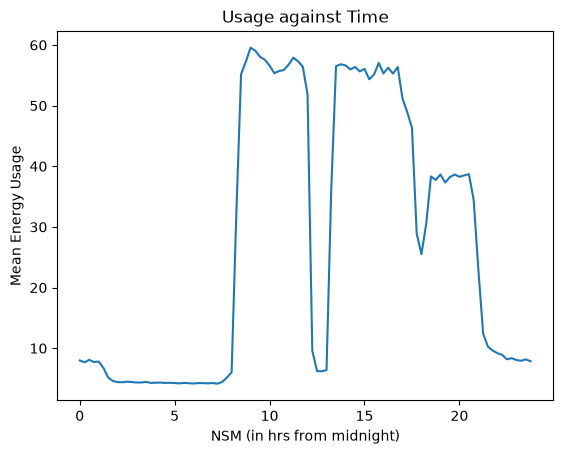

In [86]:
# plot of usage against time
df['NSM_hrs'] = df.eval('NSM/3600')
mean_nsm = df.groupby('NSM_hrs')['Usage_kWh'].mean()
fig,ax = plt.subplots()
ax.plot(mean_nsm)
ax.set_xlabel('NSM (in hrs from midnight)')
ax.set_ylabel('Mean Energy Usage')
ax.set_title('Usage against Time')

Findings: Energy consumption tends to increase significantly at 8 hrs past midnight (8am) then stays high till around noon (12pm) when it drops to low again. It then rises back to a high level around 1pm and stays high till around 6pm where it becomes moderately high and then finally goes back low around 8pm. This suggests that operation is not constant throughout the day and appears to follow specific operating periods. This pattern may reflect scheduled production or operating periods, potentially corresponding to normal working hours with a midday break, although this would require further investigation.

### Weekday vs Weekend

Does the distribution of energy consumption differ between weekdays and weekends?

In [88]:
print(df['WeekStatus'].value_counts())
print(df['WeekStatus'].value_counts(normalize = True)*100)

WeekStatus
Weekday    25056
Weekend     9984
Name: count, dtype: int64
WeekStatus
Weekday    71.506849
Weekend    28.493151
Name: proportion, dtype: float64


Text(0, 0.5, 'Energy usage')

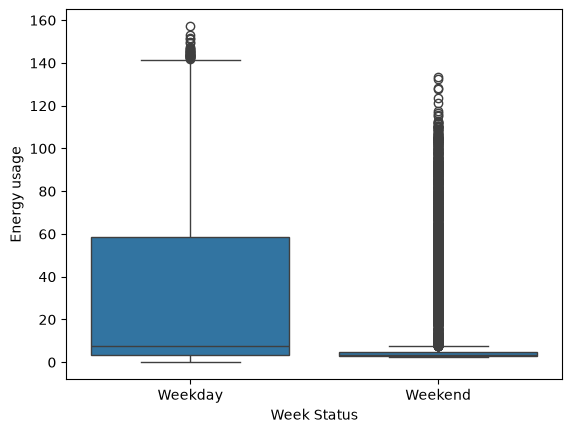

In [136]:
fig,ax = plt.subplots()
sns.boxplot(data = df, x = 'WeekStatus', y= 'Usage_kWh')
ax.set_xlabel('Week Status')
ax.set_ylabel('Energy usage')

Text(0.5, 1.0, 'Usage against Time')

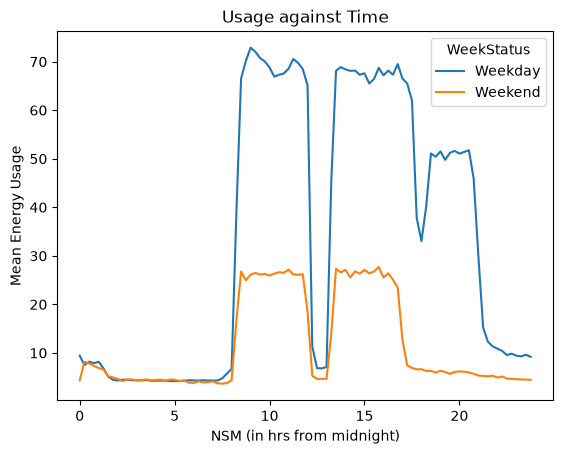

In [147]:
# weekday vs weekend plot usage vs NSM
fig,ax = plt.subplots()
sns.lineplot(data = df, x ='NSM_hrs', y = 'Usage_kWh', hue = 'WeekStatus', ax=ax, errorbar = None)
ax.set_xlabel('NSM (in hrs from midnight)')
ax.set_ylabel('Mean Energy Usage')
ax.set_title('Usage against Time')

Findings: The average daily consumption profile differs significantly between weekdays and weekends. Both groups show similar changes in consumption during similar times, however weekday consumption is significantly higher during active periods. the similar timing but different consumption levels may indicate that the facility follows an operating schedule that depends on whether it is weekend or a weekday.

### Day of Week

In [109]:
df['Day_of_week'].value_counts()

Day_of_week
Monday       5088
Tuesday      4992
Wednesday    4992
Thursday     4992
Friday       4992
Saturday     4992
Sunday       4992
Name: count, dtype: int64

In [140]:
order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
cat_type = CategoricalDtype(categories= order, ordered= True)
df['Day_of_week'] = df['Day_of_week'].astype(cat_type)

Text(0, 0.5, 'Energy Usage')

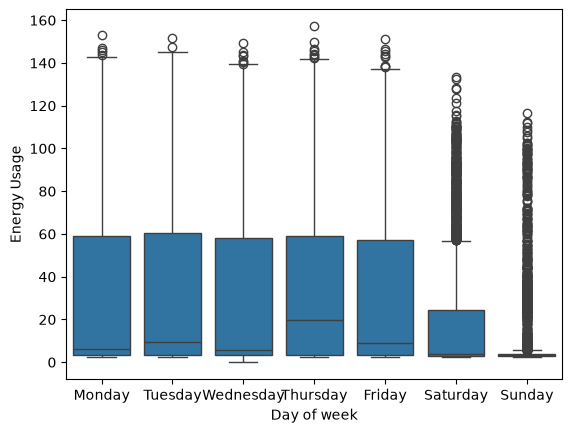

In [141]:
fig,ax = plt.subplots()
sns.boxplot(data = df, x = 'Day_of_week', y = 'Usage_kWh', ax = ax)
ax.set_xlabel('Day of week')
ax.set_ylabel('Energy Usage')

Text(0.5, 1.0, 'Usage against Time')

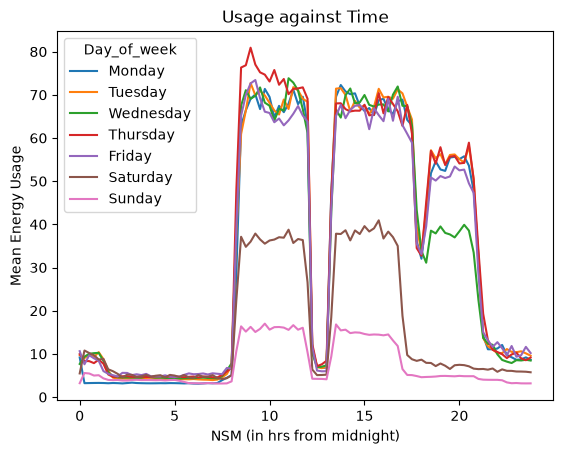

In [148]:
fig,ax = plt.subplots()
sns.lineplot(data = df, x ='NSM_hrs', y = 'Usage_kWh', hue = 'Day_of_week', ax=ax, errorbar = None)
ax.set_xlabel('NSM (in hrs from midnight)')
ax.set_ylabel('Mean Energy Usage')
ax.set_title('Usage against Time')

Findings: weekdays follow a common operating pattern, and while Saturday follows a similar pattern, it has a lower magnitude with Sunday being even lower. Thursday has a slightly higher peak to the rest of the weekdays. Lastly, the day of the week appears to affect consumption intensity more than the overall timing of the operating schedule.

### Electrical (Numerical) Variables

In [156]:
# correlation of numerical features
numerical = df[['Usage_kWh', 'Lagging_Current_Reactive.Power_kVarh',
    'Leading_Current_Reactive_Power_kVarh','CO2(tCO2)','Lagging_Current_Power_Factor',
    'Leading_Current_Power_Factor','NSM']]
correlation = numerical.corr()
correlation

,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM
Usage_kWh,1.000000,0.896150,-0.324922,0.988180,0.385960,0.353566,0.234610
Lagging_Current_Reactive.Power_kVarh,0.896150,1.000000,-0.405142,0.886948,0.144534,0.407716,0.082662
Leading_Current_Reactive_Power_kVarh,-0.324922,-0.405142,1.000000,-0.332777,0.526770,-0.944039,0.371605
CO2(tCO2),0.988180,0.886948,-0.332777,1.000000,0.379605,0.360019,0.231726
Lagging_Current_Power_Factor,0.385960,0.144534,0.526770,0.379605,1.000000,-0.519967,0.565270
Leading_Current_Power_Factor,0.353566,0.407716,-0.944039,0.360019,-0.519967,1.000000,-0.360563
NSM,0.234610,0.082662,0.371605,0.231726,0.565270,-0.360563,1.000000


<Axes: >

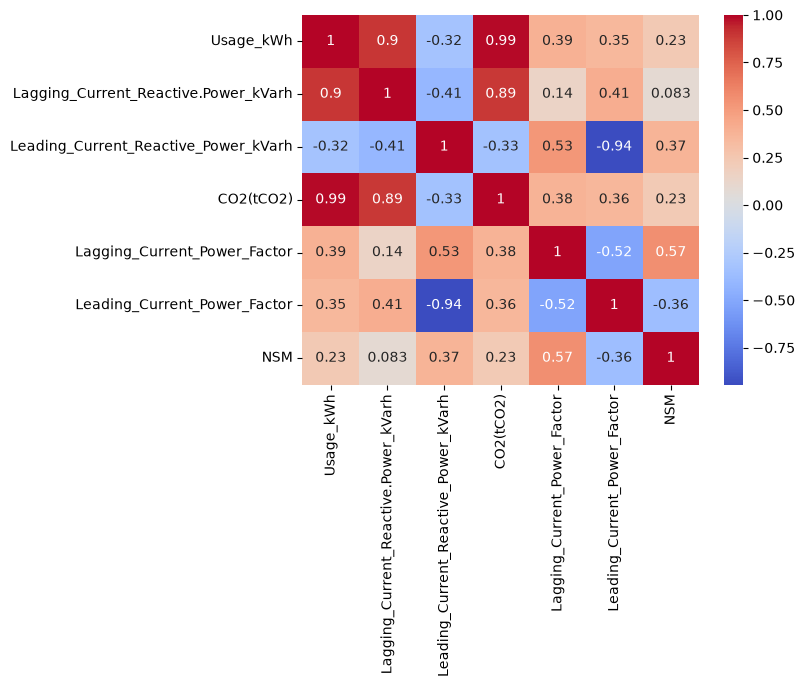

In [159]:
sns.heatmap(correlation, annot = True, cmap = 'coolwarm')

Text(0.5, 1.0, 'Correlation between Energy Usage and Lagging Current Reactive Power')

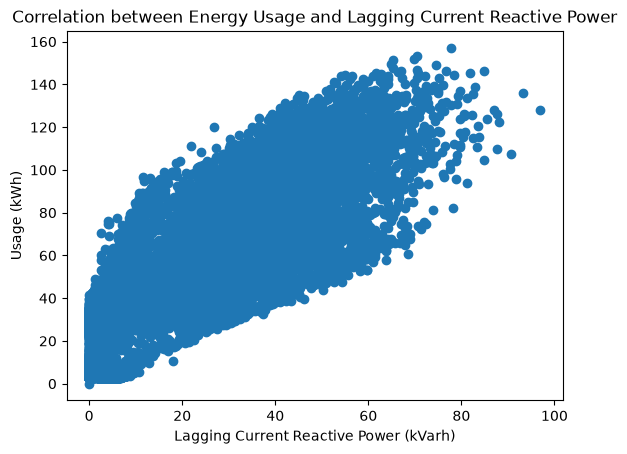

In [164]:
# Correlation between Energy Usage and Lagging Current Reactive Power
fig, ax = plt.subplots()
ax.scatter(data = df, x='Lagging_Current_Reactive.Power_kVarh', y = 'Usage_kWh')
ax.set_xlabel('Lagging Current Reactive Power (kVarh)')
ax.set_ylabel('Usage (kWh)')
ax.set_title('Correlation between Energy Usage and Lagging Current Reactive Power')

Text(0.5, 1.0, 'Correlation between Energy Usage and Lagging Current Power Factor')

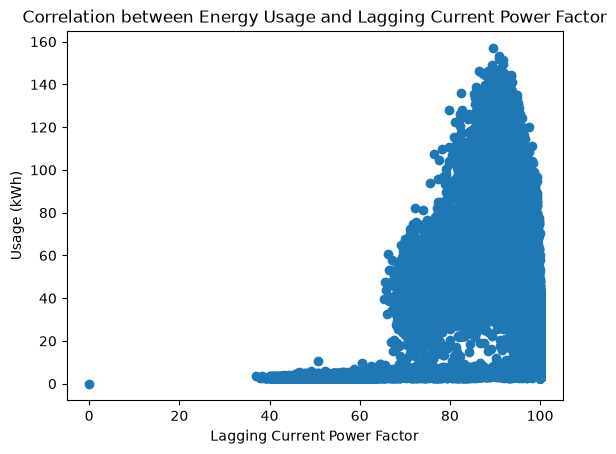

In [165]:
# Correlation between Energy Usage and Lagging Current Power Factor
fig, ax = plt.subplots()
ax.scatter(data = df, x='Lagging_Current_Power_Factor', y = 'Usage_kWh')
ax.set_xlabel('Lagging Current Power Factor')
ax.set_ylabel('Usage (kWh)')
ax.set_title('Correlation between Energy Usage and Lagging Current Power Factor')

Text(0.5, 1.0, 'Correlation between Energy Usage and Leading Current Reactive Power')

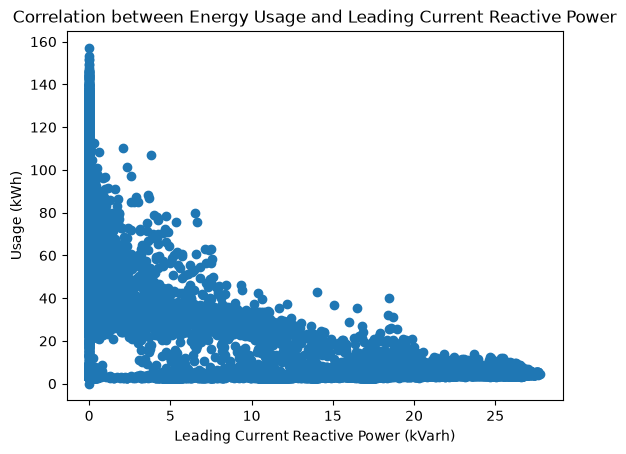

In [166]:
# Correlation between Energy Usage and Leading Current Reactive Power
fig, ax = plt.subplots()
ax.scatter(data = df, x='Leading_Current_Reactive_Power_kVarh', y = 'Usage_kWh')
ax.set_xlabel('Leading Current Reactive Power (kVarh)')
ax.set_ylabel('Usage (kWh)')
ax.set_title('Correlation between Energy Usage and Leading Current Reactive Power')

Findings: The electrical variables show varying degrees of association with energy consumption. CO₂ has an exceptionally strong association with energy consumption and therefore requires further investigation regarding its suitability as a forecasting predictor. The strong correlation between some predictors also suggests potential redundancy that should be considered.

### Other Analysis

In [176]:
df.query('Usage_kWh == 0')

,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type,NSM_hrs
29855,07/11/2018 00:00,0.0,0.0,0.0,0.0,0.0,0.0,0,Weekday,Wednesday,Light_Load,0.0


In [179]:
highest_kwh = df.sort_values(by = 'Usage_kWh', ascending = False)
highest_kwh.head(10)

,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type,NSM_hrs
31238,22/11/2018 09:45,157.18,77.72,0.0,0.07,89.64,100.0,35100,Weekday,Thursday,Medium_Load,9.75
1398,15/01/2018 13:45,153.14,70.45,0.0,0.07,90.85,100.0,49500,Weekday,Monday,Medium_Load,13.75
31723,27/11/2018 11:00,151.67,69.73,0.0,0.07,90.86,100.0,39600,Weekday,Tuesday,Maximum_Load,11.00
7812,23/03/2018 09:15,151.31,65.20,0.0,0.07,91.84,100.0,33300,Weekday,Friday,Medium_Load,9.25
1701,18/01/2018 17:30,149.65,64.87,0.0,0.07,91.75,100.0,63000,Weekday,Thursday,Maximum_Load,17.50
33848,19/12/2018 14:15,149.18,74.56,0.0,0.07,89.45,100.0,51300,Weekday,Wednesday,Medium_Load,14.25
162,02/01/2018 16:45,147.46,65.27,0.0,0.00,91.44,100.0,60300,Weekday,Tuesday,Medium_Load,16.75
6111,05/03/2018 16:00,146.88,70.49,0.0,0.07,90.16,100.0,57600,Weekday,Monday,Maximum_Load,16.00
1679,18/01/2018 12:00,146.48,84.89,0.0,0.07,86.52,100.0,43200,Weekday,Thursday,Maximum_Load,12.00
447,05/01/2018 16:00,146.34,66.92,0.0,0.07,90.94,100.0,57600,Weekday,Friday,Medium_Load,16.00


Text(0.5, 1.0, 'Correlation between Energy Usage and CO2 Emission')

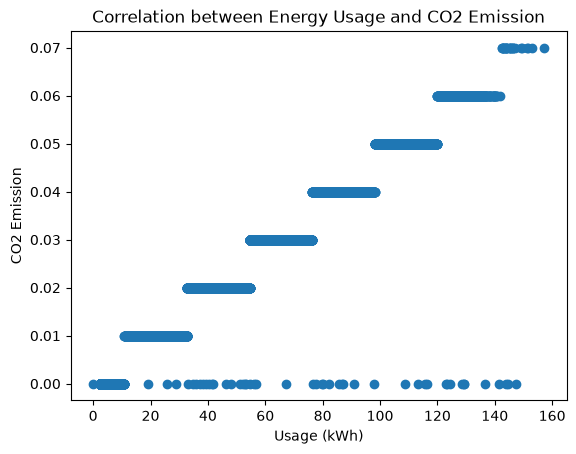

In [181]:
fig, ax = plt.subplots()
ax.scatter(df['Usage_kWh'], df['CO2(tCO2)'])
ax.set_xlabel('Usage (kWh)')
ax.set_ylabel('CO2 Emission')
ax.set_title('Correlation between Energy Usage and CO2 Emission')

Findings: The dataset contains only one zero-usage observation with zero electrical observations suggesting a possible recording issue rather than genuine zero consumption. The extreme energy consumption values appear to be genuine because they occur during operating periods and have plausible electrical measurements. Lastly, CO₂ emissions show an extremely strong relationship with energy usage, with emissions increasing in discrete steps as usage increases. However, CO₂ emissions were excluded from the forecasting features because their availability at prediction time is uncertain, and using a variable that reflects contemporaneous energy consumption could introduce information leakage.

### Summary

Overall, the EDA revealed that the dataset is largely clean and represents a structured time series of industrial energy consumption. Energy usage varies considerably across time of day, day of week, weekday/weekend status, and load conditions. The electrical variables also show varying degrees of association with energy consumption. The analysis suggests that energy consumption is influenced by multiple factors rather than a single variable, making a multivariable forecasting approach more appropriate.